# PART B — PREDICTIVE MODELING

In [5]:
# LIBRARY IMPORTS

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train / Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Classification Evaluation
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    classification_report
)
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Class Imbalance — SMOTE
from imblearn.over_sampling import SMOTE

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Saving / Loading Complete ML Pipeline
import joblib

# Display confirmation
print("All modeling libraries imported successfully.")

All modeling libraries imported successfully.


In [9]:
# STEP 1 — STRATIFIED TRAIN / TEST SPLIT

#load the dataset
df=pd.read_csv("titanic.csv")

# Separate features (X) and classification target (y)
X = df.drop(columns=["survived"])
y = df["survived"]

# Perform an 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the resulting shapes
print("Original dataset shape:", df.shape)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# Check class distribution before and after splitting
print("\nOriginal class distribution:")
print(y.value_counts(normalize=True).sort_index())

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Original dataset shape: (891, 15)

Training set:
X_train: (712, 14)
y_train: (712,)

Testing set:
X_test: (179, 14)
y_test: (179,)

Original class distribution:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Training class distribution:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing class distribution:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


## Stratified Train/Test Split — Interpretation

The cleaned Titanic dataset was divided into 80% training data and 20% testing data using a stratified split with `survived` as the target variable. The original dataset contains approximately 61.62% passengers who did not survive and 38.38% passengers who survived. After splitting, the training set contains 61.66% non-survivors and 38.34% survivors, while the testing set contains 61.45% non-survivors and 38.55% survivors. The class proportions remain very similar across the original, training, and testing datasets, showing that stratification successfully preserved the class balance.

#
#

In [10]:
# STEP 2 — PREPROCESSING

# STEP 2.1 — IDENTIFY NUMERICAL AND CATEGORICAL FEATURES

# Identify categorical columns
categorical_features = ["sex", "embarked"]

# Identify numerical columns
numerical_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

# Display the selected features
print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

print("\nTotal Features Used:", len(categorical_features) + len(numerical_features))

Categorical Features:
['sex', 'embarked']

Numerical Features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Total Features Used: 7


In [11]:
# STEP 2.2 — BUILD PREPROCESSING PIPELINES


# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipelines created successfully.")

Preprocessing pipelines created successfully.


In [12]:
# STEP 2.3 — FIT AND TRANSFORM PREPROCESSOR

# Fit the preprocessor only on training data
preprocessor.fit(X_train)

# Transform training data
X_train_processed = preprocessor.transform(X_train)

# Transform testing data
X_test_processed = preprocessor.transform(X_test)

# Display the processed data shapes
print("Original Training Shape:", X_train.shape)
print("Processed Training Shape:", X_train_processed.shape)

print("\nOriginal Testing Shape:", X_test.shape)
print("Processed Testing Shape:", X_test_processed.shape)

# Confirm preprocessing was applied successfully
print("\nPreprocessing completed successfully.")

Original Training Shape: (712, 14)
Processed Training Shape: (712, 10)

Original Testing Shape: (179, 14)
Processed Testing Shape: (179, 10)

Preprocessing completed successfully.


In [13]:
# STEP 3 — CREATE CLASSIFICATION MODELS

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    random_state=42
)

# Display the models
print("Classification models created successfully.")

print("\nLogistic Regression:")
print(logistic_model)

print("\nDecision Tree:")
print(decision_tree_model)

print("\nRandom Forest:")
print(random_forest_model)

Classification models created successfully.

Logistic Regression:
LogisticRegression(max_iter=1000, random_state=42)

Decision Tree:
DecisionTreeClassifier(random_state=42)

Random Forest:
RandomForestClassifier(random_state=42)


In [14]:
# STEP 3.1 — CREATE COMPLETE CLASSIFICATION PIPELINES

# Create Logistic Regression pipeline
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", logistic_model)
])

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", decision_tree_model)
])

# Create Random Forest pipeline
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", random_forest_model)
])

# Display pipeline creation status
print("Classification pipelines created successfully.")

Classification pipelines created successfully.


In [15]:
# STEP 3.2 — TRAIN THE THREE CLASSIFIERS

# Train Logistic Regression
logistic_pipeline.fit(X_train, y_train)

# Train Decision Tree
decision_tree_pipeline.fit(X_train, y_train)

# Train Random Forest
random_forest_pipeline.fit(X_train, y_train)

# Display training status
print("All three classification models trained successfully.")

All three classification models trained successfully.


In [16]:
# STEP 4 — MAKE PREDICTIONS

# Make predictions using Logistic Regression
y_pred_logistic = logistic_pipeline.predict(X_test)

# Make predictions using Decision Tree
y_pred_decision_tree = decision_tree_pipeline.predict(X_test)

# Make predictions using Random Forest
y_pred_random_forest = random_forest_pipeline.predict(X_test)

# Display prediction status
print("Predictions generated successfully.")

print("\nPrediction Shapes:")
print("Logistic Regression:", y_pred_logistic.shape)
print("Decision Tree:", y_pred_decision_tree.shape)
print("Random Forest:", y_pred_random_forest.shape)

Predictions generated successfully.

Prediction Shapes:
Logistic Regression: (179,)
Decision Tree: (179,)
Random Forest: (179,)


In [17]:
# STEP 4.1 — CALCULATE CLASSIFICATION METRICS

# Calculate metrics for Logistic Regression
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

# Calculate metrics for Decision Tree
decision_tree_accuracy = accuracy_score(y_test, y_pred_decision_tree)
decision_tree_precision = precision_score(y_test, y_pred_decision_tree)
decision_tree_recall = recall_score(y_test, y_pred_decision_tree)
decision_tree_f1 = f1_score(y_test, y_pred_decision_tree)

# Calculate metrics for Random Forest
random_forest_accuracy = accuracy_score(y_test, y_pred_random_forest)
random_forest_precision = precision_score(y_test, y_pred_random_forest)
random_forest_recall = recall_score(y_test, y_pred_random_forest)
random_forest_f1 = f1_score(y_test, y_pred_random_forest)

# Display the results
print("Logistic Regression")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

print("\nDecision Tree")
print("Accuracy :", decision_tree_accuracy)
print("Precision:", decision_tree_precision)
print("Recall   :", decision_tree_recall)
print("F1 Score :", decision_tree_f1)

print("\nRandom Forest")
print("Accuracy :", random_forest_accuracy)
print("Precision:", random_forest_precision)
print("Recall   :", random_forest_recall)
print("F1 Score :", random_forest_f1)

Logistic Regression
Accuracy : 0.8044692737430168
Precision: 0.7931034482758621
Recall   : 0.6666666666666666
F1 Score : 0.7244094488188977

Decision Tree
Accuracy : 0.8156424581005587
Precision: 0.7903225806451613
Recall   : 0.7101449275362319
F1 Score : 0.7480916030534351

Random Forest
Accuracy : 0.8156424581005587
Precision: 0.8
Recall   : 0.6956521739130435
F1 Score : 0.7441860465116279


In [18]:
# STEP 4.2 — CONFUSION MATRICES

# Calculate confusion matrices
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_decision_tree = confusion_matrix(y_test, y_pred_decision_tree)
cm_random_forest = confusion_matrix(y_test, y_pred_random_forest)

# Display Logistic Regression confusion matrix
print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

# Display Decision Tree confusion matrix
print("\nDecision Tree Confusion Matrix:")
print(cm_decision_tree)

# Display Random Forest confusion matrix
print("\nRandom Forest Confusion Matrix:")
print(cm_random_forest)

Logistic Regression Confusion Matrix:
[[98 12]
 [23 46]]

Decision Tree Confusion Matrix:
[[97 13]
 [20 49]]

Random Forest Confusion Matrix:
[[98 12]
 [21 48]]


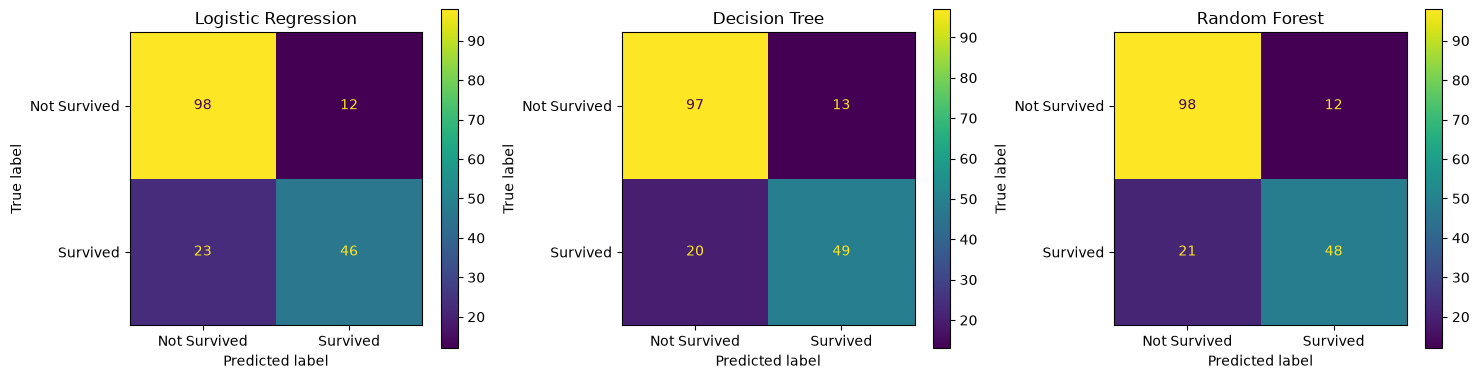

In [19]:
# STEP 4.3 — VISUALIZE CONFUSION MATRICES

# Create figure for all three confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Survived", "Survived"]
).plot(ax=axes[0])

axes[0].set_title("Logistic Regression")

# Decision Tree confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_decision_tree,
    display_labels=["Not Survived", "Survived"]
).plot(ax=axes[1])

axes[1].set_title("Decision Tree")

# Random Forest confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_random_forest,
    display_labels=["Not Survived", "Survived"]
).plot(ax=axes[2])

axes[2].set_title("Random Forest")

# Adjust layout
plt.tight_layout()

# Display the plots
plt.show()

In [20]:
# STEP 4.4 — ROC CURVES AND AUC

# Get probability of the positive class (Survived = 1)
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_decision_tree = decision_tree_pipeline.predict_proba(X_test)[:, 1]
y_prob_random_forest = random_forest_pipeline.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_decision_tree, tpr_decision_tree, _ = roc_curve(y_test, y_prob_decision_tree)
fpr_random_forest, tpr_random_forest, _ = roc_curve(y_test, y_prob_random_forest)

# Calculate AUC values
auc_logistic = roc_auc_score(y_test, y_prob_logistic)
auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)
auc_random_forest = roc_auc_score(y_test, y_prob_random_forest)

# Display AUC values
print("ROC-AUC Scores:")

print("Logistic Regression:", auc_logistic)
print("Decision Tree      :", auc_decision_tree)
print("Random Forest      :", auc_random_forest)

ROC-AUC Scores:
Logistic Regression: 0.8437417654808959
Decision Tree      : 0.7903820816864295
Random Forest      : 0.8287220026350461


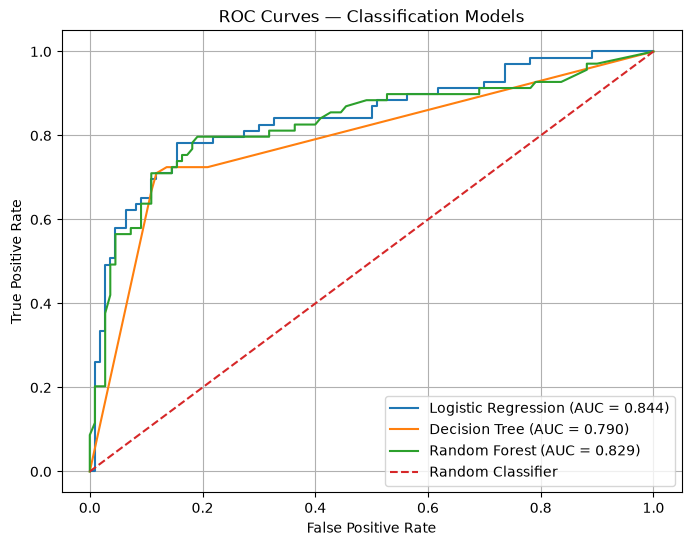

In [21]:
# STEP 4.5 — ROC CURVE VISUALIZATION

# Create ROC curve plot
plt.figure(figsize=(8, 6))

# Plot Logistic Regression ROC curve
plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

# Plot Decision Tree ROC curve
plt.plot(
    fpr_decision_tree,
    tpr_decision_tree,
    label=f"Decision Tree (AUC = {auc_decision_tree:.3f})"
)

# Plot Random Forest ROC curve
plt.plot(
    fpr_random_forest,
    tpr_random_forest,
    label=f"Random Forest (AUC = {auc_random_forest:.3f})"
)

# Plot random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

# Add plot labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Models")

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Show plot
plt.show()

In [22]:
# STEP 4.6 — CLASSIFICATION MODEL COMPARISON

# Create classification model comparison table
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision
    ],
    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall
    ],
    "F1 Score": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1
    ],
    "AUC": [
        auc_logistic,
        auc_decision_tree,
        auc_random_forest
    ]
})

# Display the comparison table
classification_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
1,Decision Tree,0.815642,0.790323,0.710145,0.748092,0.790382
2,Random Forest,0.815642,0.800000,0.695652,0.744186,0.828722


In [23]:
# STEP 5 — CLASS IMBALANCE HANDLING

# STEP 5.1 — REPORT CLASS BALANCE

# Count the number of samples in each class
class_counts = y.value_counts().sort_index()

# Calculate class percentages
class_percentages = y.value_counts(normalize=True).sort_index() * 100

# Display class counts
print("Class Counts:")
print(class_counts)

# Display class percentages
print("\nClass Percentages:")
print(class_percentages)

# Display class balance
print("\nClass Balance:")
print(f"Not Survived (0): {class_counts[0]} ({class_percentages[0]:.2f}%)")
print(f"Survived (1): {class_counts[1]} ({class_percentages[1]:.2f}%)")

Class Counts:
survived
0    549
1    342
Name: count, dtype: int64

Class Percentages:
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Class Balance:
Not Survived (0): 549 (61.62%)
Survived (1): 342 (38.38%)


In [24]:
# STEP 5.2 — BASELINE LOGISTIC REGRESSION

# Create baseline Logistic Regression pipeline
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train baseline model
baseline_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_baseline = baseline_pipeline.predict(X_test)

# Calculate baseline metrics
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

# Display results
print("Baseline Logistic Regression")
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1 Score :", baseline_f1)

Baseline Logistic Regression
Precision: 0.7931034482758621
Recall   : 0.6666666666666666
F1 Score : 0.7244094488188977


In [25]:
# STEP 5.3 — LOGISTIC REGRESSION WITH BALANCED CLASS WEIGHTS

# Create Logistic Regression pipeline with balanced class weights
balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train the balanced model
balanced_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_balanced = balanced_pipeline.predict(X_test)

# Calculate metrics
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)

# Display results
print("Balanced Logistic Regression")
print("Precision:", balanced_precision)
print("Recall   :", balanced_recall)
print("F1 Score :", balanced_f1)

Balanced Logistic Regression
Precision: 0.7297297297297297
Recall   : 0.782608695652174
F1 Score : 0.7552447552447552


In [26]:
# STEP 5.4 — SMOTE OVERSAMPLING

# Create a fresh preprocessor for the SMOTE experiment
smote_preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Fit preprocessing only on training data
X_train_processed_smote = smote_preprocessor.fit_transform(X_train)

# Transform testing data using the fitted preprocessor
X_test_processed_smote = smote_preprocessor.transform(X_test)

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed_smote,
    y_train
)

# Display class distribution before and after SMOTE
print("Training Class Distribution Before SMOTE:")
print(y_train.value_counts())

print("\nTraining Class Distribution After SMOTE:")
print(y_train_smote.value_counts())

# Create Logistic Regression model
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model on SMOTE-resampled training data
smote_model.fit(X_train_smote, y_train_smote)

# Make predictions on the original test data
y_pred_smote = smote_model.predict(X_test_processed_smote)

# Calculate metrics
smote_precision = precision_score(y_test, y_pred_smote)
smote_recall = recall_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)

# Display results
print("\nSMOTE Logistic Regression")
print("Precision:", smote_precision)
print("Recall   :", smote_recall)
print("F1 Score :", smote_f1)

Training Class Distribution Before SMOTE:
survived
0    439
1    273
Name: count, dtype: int64

Training Class Distribution After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

SMOTE Logistic Regression
Precision: 0.7397260273972602
Recall   : 0.782608695652174
F1 Score : 0.7605633802816901


In [27]:
# STEP 5.5 — IMBALANCE HANDLING COMPARISON

# Create comparison table
imbalance_results = pd.DataFrame({
    "Strategy": [
        "Baseline",
        "class_weight='balanced'",
        "SMOTE"
    ],
    "Precision": [
        baseline_precision,
        balanced_precision,
        smote_precision
    ],
    "Recall": [
        baseline_recall,
        balanced_recall,
        smote_recall
    ],
    "F1 Score": [
        baseline_f1,
        balanced_f1,
        smote_f1
    ]
})

# Display the comparison table
imbalance_results

,Strategy,Precision,Recall,F1 Score
0,Baseline,0.793103,0.666667,0.724409
1,class_weight='balanced',0.729730,0.782609,0.755245
2,SMOTE,0.739726,0.782609,0.760563


## Imbalance Handling — Conclusion

The baseline Logistic Regression model achieved a precision of 0.7931, recall of 0.6667, and F1 score of 0.7244. Using `class_weight='balanced'` increased recall to 0.7826 and F1 score to 0.7552, although precision decreased to 0.7297. SMOTE produced a precision of 0.7397, recall of 0.7826, and F1 score of 0.7606. In this experiment, SMOTE produced the highest F1 score among the three approaches, while both balanced class weighting and SMOTE provided higher recall than the baseline.

#